# Research Assignment 1: Recommender System Type Analysis (Python Implementation, real data)

**Course:** AAI 6650 Recommendation Engines, Module 2
**Domain:** Course recommendations on a corporate upskilling (Learning & Development) platform
**Data:** real learner–course enrollments from the IBM Skills Network course recommender dataset (33,901 learners, 126 courses)

This notebook builds on the Module 1 hands-on notebook. It compares all four recommender system types on **one shared dataset** and **one target learner**:

| § | Approach | Signal used |
|---|---|---|
| 1 | Dataset | Real IBM enrollments, a 12 × 15 working matrix, and course genre tags |
| 2 | User-based collaborative filtering (CF) | Other learners' enrollments |
| 3 | Content-based filtering (CBF) | IBM course genre tags plus the target's own history |
| 4 | Knowledge-based filtering (KBS, constraint-based) | Stated goals plus a prerequisite knowledge base (no rating data needed) |
| 5 | Hybrid (prerequisite gate, then adaptive weighted blend) | KBS hard constraints, then a weighted blend of CF, CBF and KBS |
| 6 | Comparison | Top-5 table, grouped bar chart, overlap matrix, commentary |
| 7 | Cold-start check | The same methods run for a real learner with a single enrollment |
| 8 | Scale check | User-based CF over the full 33,901-learner platform |

**Runs in Google Colab with no setup.** It uses only `numpy`, `matplotlib` and the Python standard library (`urllib`, `csv`), and no recommender libraries. The data downloads from IBM's public storage. If the download fails, an embedded copy of the 12 × 15 working matrix is used, so every section except §8 still runs.

In [1]:
import csv, io, os, urllib.request
import numpy as np
%pip install -q matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def save_fig(fig, name):
    # Keep a PDF copy of each figure for the written report (harmless in Colab).
    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/{name}.pdf", bbox_inches="tight")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\subha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 1. Dataset: real learner–course matrix (12 learners × 15 courses)

**Source.** The IBM Skills Network dataset used in the course recommender labs of IBM's [*Machine Learning Capstone*](https://www.coursera.org/learn/machine-learning-capstone) on Coursera (IBM Skills Network, n.d.-a, n.d.-b). It comes from an online technical-upskilling platform, which is the closest public match to a corporate L&D catalog. Three files are used:

- `ratings.csv`: 233,306 enrollments by 33,901 anonymous learners on 126 courses.
- `course_genre.csv`: 14 binary genre tags per course (Python, MachineLearning, CloudComputing, BigData, and so on).
- The course titles, which come from the same file.

**What a "rating" means here.** IBM's lab documentation, *Exploratory Data Analysis on Online Course Enrollment Data* (Luo, 2021; public copy in Boccenti, 2023: [lab notebook](https://github.com/mboccenti/Recommender_system_project/blob/main/01.%20Exploratory%20Data%20Analysis%20on%20Online%20Course%20Enrollment%20Data.ipynb)), defines the value as the *enrollment mode*: **3 = completed the course and earned a certificate**, **2 = audited without completing**. Browsing (1) and no interaction (0) are not recorded. This is **implicit, near-binary feedback**, not a 1–5 satisfaction score, and 95% of the values are 3. Several findings below come directly from this.

**Why this dataset.** Real corporate L&D logs are confidential. MovieLens and Amazon reviews have no course metadata, and this dataset has real enrollments *and* real course metadata. It has no course duration, difficulty or stated learning goals, so the KBS in §4 adds a small authored knowledge base (course levels and prerequisites) and a hypothetical learning-goals form. Both are labeled clearly as authored.

**How the 12 × 15 working matrix is built (fixed rules, no hand-editing of values):**
- **Courses:** 15 popular courses that cover 12 of the 14 genre tags, from Python and SQL to deep learning, Spark, cloud, chatbots and blockchain.
- **Target learner (#1008779):** chosen from the 63 learners who have 5–7 of these courses including at least one audit and one completion. This learner's history (Python, SQL, statistics, data analysis, data visualization, Docker; *audited* Intro to Data Science) matches a data-analyst persona.
- **10 peers:** drawn at random (seed 42) from learners with 4–10 of the 15 courses.
- **Cold-start learner:** drawn at random from learners whose *only* enrollment on the whole platform is one of these courses. Used in §7.

In [2]:
# ----- 1a. Download the public IBM Skills Network course data (no login needed) -----
BASE = ("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
        "IBM-ML321EN-SkillsNetwork/labs/datasets/")

def fetch_csv(name):
    with urllib.request.urlopen(BASE + name, timeout=60) as resp:
        return list(csv.DictReader(io.StringIO(resp.read().decode("utf-8-sig"))))

try:
    ratings_rows = fetch_csv("ratings.csv")        # user, item, rating (2 = audit, 3 = completed)
    genre_rows = fetch_csv("course_genre.csv")     # COURSE_ID, TITLE, 14 binary genre columns
    ONLINE = True
except Exception as err:                           # offline fallback: embedded copy of the subset
    print(f"Download failed ({err}); using the embedded 12 x 15 subset instead.")
    ONLINE = False

GENRES = ["Database", "Python", "CloudComputing", "DataAnalysis", "Containers", "MachineLearning",
          "ComputerVision", "DataScience", "BigData", "Chatbot", "R", "BackendDev", "FrontendDev",
          "Blockchain"]

if ONLINE:
    all_users = sorted({int(r["user"]) for r in ratings_rows})
    all_items = sorted({r["item"] for r in ratings_rows})
    uidx = {u: k for k, u in enumerate(all_users)}
    iidx = {c: k for k, c in enumerate(all_items)}
    R_full = np.zeros((len(all_users), len(all_items)), dtype=np.float32)
    for r in ratings_rows:
        R_full[uidx[int(r["user"])], iidx[r["item"]]] = float(r["rating"])
    genre_of = {g["COURSE_ID"]: np.array([int(g[k]) for k in GENRES], dtype=float) for g in genre_rows}
    vals, counts = np.unique(R_full[R_full > 0], return_counts=True)
    print(f"Full dataset: {len(ratings_rows):,} enrollments, {len(all_users):,} learners, "
          f"{len(all_items)} courses")
    print(f"Sparsity: {1 - len(ratings_rows) / R_full.size:.2%} of cells empty")
    print("Rating values:", {f"{v:.0f} ({'completed' if v == 3 else 'audited'})": int(c)
                             for v, c in zip(vals, counts)})
    per_user = (R_full > 0).sum(1)
    print(f"Courses per learner: median {np.median(per_user):.0f}, max {per_user.max()}")

Full dataset: 233,306 enrollments, 33,901 learners, 126 courses
Sparsity: 94.54% of cells empty
Rating values: {'2 (audited)': 10976, '3 (completed)': 222330}
Courses per learner: median 6, max 61


In [3]:
# ----- 1b. Working matrix: 12 real learners x 15 real courses -----
# 15 popular courses chosen to span 12 of the 14 IBM genre tags (a small L&D catalog).
COURSES = ["PY0101EN", "DS0101EN", "DB0101EN", "DA0101EN", "DV0101EN", "ST0101EN", "ML0101ENv3",
           "ML0115EN", "ML0120ENv2", "BD0101EN", "BD0211EN", "CC0101EN", "CO0101EN", "CB0103EN",
           "BC0101EN"]
items = ["Python for Data Science", "Introduction to Data Science", "SQL & Relational DBs 101",
         "Data Analysis with Python", "Data Visualization with Python", "Statistics 101",
         "Machine Learning with Python", "Deep Learning 101", "Deep Learning with TensorFlow",
         "Big Data 101", "Spark Fundamentals I", "Introduction to Cloud", "Docker Essentials",
         "Build Your Own Chatbot", "Blockchain Essentials"]
short = ["Python", "IntroDS", "SQL", "DataAnlys", "DataViz", "Stats", "ML-Py", "DL-101",
         "DL-TF", "BigData", "Spark", "Cloud", "Docker", "Chatbot", "Blockchain"]

# Offline fallback: an exact copy of the 12 x 15 subset built below (used only if the download fails)
FALLBACK_USERS = [1008779, 602323, 1582751, 609548, 1395467, 1106915, 1099831, 1463478, 619793, 770073, 1725146, 509763]
FALLBACK_TOTAL = [12, 7, 7, 16, 8, 7, 6, 13, 10, 9, 5, 1]
FALLBACK_POP = [14936, 14477, 3697, 8303, 6709, 5015, 7644, 6323, 2565, 13291, 7551, 4983, 4480, 5512, 6719]
FALLBACK_R = [[3, 2, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0],
              [0, 3, 0, 0, 0, 0, 3, 3, 3, 0, 0, 0, 0, 0, 0],
              [3, 0, 3, 3, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 0],
              [3, 3, 0, 0, 0, 3, 0, 3, 0, 0, 3, 0, 0, 0, 0],
              [3, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0],
              [3, 3, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 3],
              [3, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3],
              [3, 3, 0, 0, 3, 3, 0, 0, 0, 3, 3, 0, 0, 0, 0],
              [3, 3, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0],
              [3, 0, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 3, 0, 3],
              [3, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 0, 0, 0],
              [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
FALLBACK_F = [[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
              [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
              [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
              [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
              [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1]]

TARGET_ID = 1008779   # a real learner whose history looks like a data analyst (see markdown above)

if ONLINE:
    R15 = R_full[:, [iidx[c] for c in COURSES]]
    in_subset = (R15 > 0).sum(1)
    total = (R_full > 0).sum(1)
    rng = np.random.default_rng(42)
    # 10 peers: random learners with 4-10 of the 15 courses (enough overlap to compare)
    pool = [u for u in all_users if 4 <= in_subset[uidx[u]] <= 10 and u != TARGET_ID]
    peers = [int(p) for p in rng.choice(pool, 10, replace=False)]
    # 1 cold-start learner: someone whose ONLY enrollment on the whole platform is one of these courses
    cold_pool = [u for u in all_users if total[uidx[u]] == 1 and in_subset[uidx[u]] == 1]
    COLD_ID = int(rng.choice(cold_pool))
    user_ids = [TARGET_ID] + peers + [COLD_ID]
    R = R15[[uidx[u] for u in user_ids]].astype(float)
    F = np.array([genre_of[c] for c in COURSES])
    n_total = [int(total[uidx[u]]) for u in user_ids]
    pop = np.array([(R_full[:, iidx[c]] > 0).sum() for c in COURSES], dtype=float)
else:
    user_ids = FALLBACK_USERS; R = np.array(FALLBACK_R, dtype=float)
    F = np.array(FALLBACK_F, dtype=float); n_total = FALLBACK_TOTAL; COLD_ID = user_ids[-1]
    pop = np.array(FALLBACK_POP, dtype=float)

users = [f"#{u}" for u in user_ids]
roles = [f"{n} course{'s' if n != 1 else ''} on platform" for n in n_total]
roles[0] += " (target)"; roles[-1] += " (cold start)"
n_users, n_items = R.shape
TARGET = 0
TOP_K_NEIGHBORS, TOP_N = 3, 5

rated_mask = R > 0
print(f"Matrix: {n_users} users x {n_items} items")
print(f"Sparsity: {1 - rated_mask.mean():.0%} of cells unrated;  audits (2): {(R == 2).sum()},  "
      f"completions (3): {(R == 3).sum()}")
print(f"Enrollments per course in this matrix: {dict(zip(short, rated_mask.sum(0).tolist()))}")
print(f"Enrollments per course on the platform: {dict(zip(short, pop.astype(int).tolist()))}")
print(f"\nTarget user: {users[TARGET]} ({roles[TARGET]})")
print("  Rated:  ", {short[j]: int(R[TARGET, j]) for j in np.where(rated_mask[TARGET])[0]})
print("  Unrated candidates:", [short[j] for j in np.where(~rated_mask[TARGET])[0]])
print(f"Cold-start user: {users[-1]} ({roles[-1]}):",
      {short[j]: int(R[-1, j]) for j in np.where(rated_mask[-1])[0]})

Matrix: 12 users x 15 items
Sparsity: 69% of cells unrated;  audits (2): 2,  completions (3): 54
Enrollments per course in this matrix: {'Python': 10, 'IntroDS': 7, 'SQL': 2, 'DataAnlys': 5, 'DataViz': 4, 'Stats': 3, 'ML-Py': 4, 'DL-101': 4, 'DL-TF': 1, 'BigData': 4, 'Spark': 4, 'Cloud': 2, 'Docker': 2, 'Chatbot': 1, 'Blockchain': 3}
Enrollments per course on the platform: {'Python': 14936, 'IntroDS': 14477, 'SQL': 3697, 'DataAnlys': 8303, 'DataViz': 6709, 'Stats': 5015, 'ML-Py': 7644, 'DL-101': 6323, 'DL-TF': 2565, 'BigData': 13291, 'Spark': 7551, 'Cloud': 4983, 'Docker': 4480, 'Chatbot': 5512, 'Blockchain': 6719}

Target user: #1008779 (12 courses on platform (target))
  Rated:   {'Python': 3, 'IntroDS': 2, 'SQL': 3, 'DataAnlys': 3, 'DataViz': 3, 'Stats': 3, 'Docker': 3}
  Unrated candidates: ['ML-Py', 'DL-101', 'DL-TF', 'BigData', 'Spark', 'Cloud', 'Chatbot', 'Blockchain']
Cold-start user: #509763 (1 course on platform (cold start)): {'IntroDS': 2}


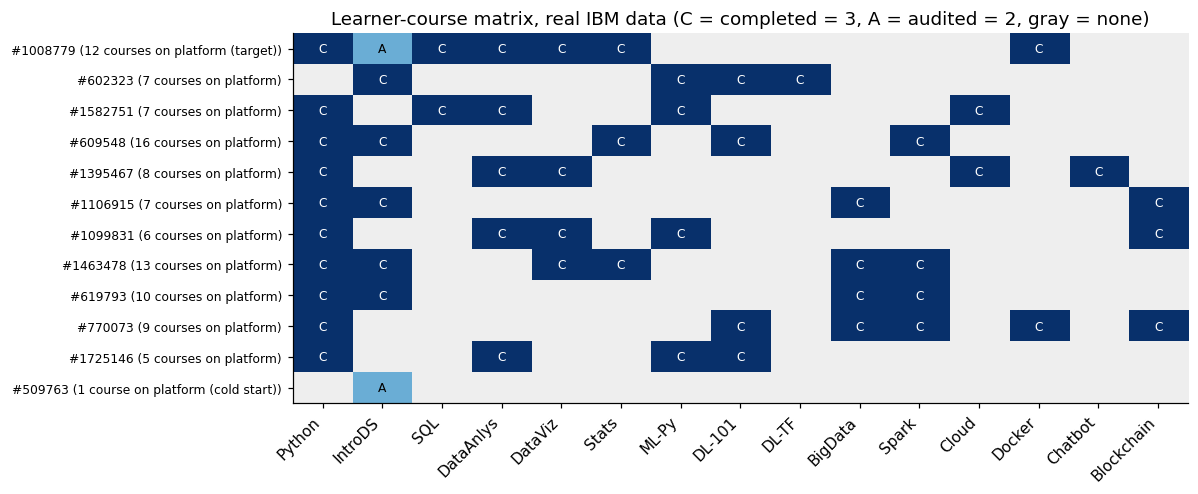

In [4]:
# Heatmap of the ratings matrix (gray = no enrollment)
fig, ax = plt.subplots(figsize=(11, 4.6))
masked = np.ma.masked_where(R == 0, R)
cmap = plt.cm.Blues.copy(); cmap.set_bad("#eeeeee")
im = ax.imshow(masked, cmap=cmap, vmin=1, vmax=3, aspect="auto")
ax.set_xticks(range(n_items), short, rotation=45, ha="right")
ax.set_yticks(range(n_users), [f"{u} ({r})" for u, r in zip(users, roles)], fontsize=8)
for i in range(n_users):
    for j in range(n_items):
        if R[i, j] > 0:
            ax.text(j, i, "C" if R[i, j] == 3 else "A", ha="center", va="center",
                    color="white" if R[i, j] == 3 else "black", fontsize=8)
ax.set_title("Learner-course matrix, real IBM data (C = completed = 3, A = audited = 2, gray = none)")
plt.tight_layout(); save_fig(fig, "fig_ratings_matrix"); plt.show()

## 2. User-based collaborative filtering

1. Compute **cosine similarity** between the target learner's vector and every other learner's vector. Empty cells count as 0, so the numerator only picks up shared courses.
2. Choose the **top-3 nearest neighbors**.
3. For each course the target hasn't taken, predict a score as the **similarity-weighted average** of the neighbors' values (only neighbors who took that course count):

$$\hat r_{u,i} = \frac{\sum_{v \in N_k(u),\, r_{v,i}>0} \text{sim}(u,v)\, r_{v,i}}{\sum_{v \in N_k(u),\, r_{v,i}>0} |\text{sim}(u,v)|}$$

If none of the three neighbors took a course, CF **cannot score it**. Because almost every value is 3, most predictions come out as exactly 3.00. The code therefore also reports **support**: the share of the neighbors' total similarity that backs each prediction. Support breaks ties, so a course two neighbors completed ranks above one that only one neighbor completed.

In [5]:
def cosine_sim(a, b):
    # Cosine similarity between two vectors. Returns 0 if either vector is all zeros.
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(a @ b / denom) if denom > 0 else 0.0

def user_similarity_matrix(R):
    # Pairwise user-user cosine similarity (unrated cells are 0).
    norms = np.linalg.norm(R, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Rn = R / norms
    return Rn @ Rn.T

def user_cf_scores(R, u, k=TOP_K_NEIGHBORS):
    # Predict ratings for u's unrated items from u's top-k neighbours.
    # Returns predictions (NaN where no neighbour rated the item), neighbour indices, sims, and
    # support = share of the neighbours' total similarity that stands behind each prediction.
    sims = np.array([cosine_sim(R[u], R[v]) if v != u else -np.inf for v in range(len(R))])
    neighbors = np.argsort(-sims, kind="stable")[:k]      # stable: ties keep matrix order
    preds, support = np.full(R.shape[1], np.nan), np.zeros(R.shape[1])
    for i in np.where(R[u] == 0)[0]:
        raters = [v for v in neighbors if R[v, i] > 0]
        if raters:
            w = sims[raters]
            preds[i] = float(w @ R[raters, i] / np.abs(w).sum())
            support[i] = np.abs(w).sum() / np.abs(sims[neighbors]).sum()
    return preds, neighbors, sims, support

S = user_similarity_matrix(R)
cf_pred, neighbors, sims, cf_support = user_cf_scores(R, TARGET)

print(f"Cosine similarity of {users[TARGET]} to every other user:")
for v in np.argsort(-sims, kind="stable"):
    if v == TARGET: continue
    tag = "  <-- top-3 neighbor" if v in neighbors else ""
    print(f"  {users[v]:<9} ({roles[v]:<36}) {sims[v]:.3f}{tag}")
kth = sims[neighbors[-1]]
tied = [users[v] for v in range(n_users) if v != TARGET and np.isclose(sims[v], kth)]
if len(tied) > 1:
    print(f"\nTie: {len(tied)} users share similarity {kth:.3f} ({', '.join(tied)}); "
          f"the 3rd neighbor slot is decided by matrix order, not by the data.")

Cosine similarity of #1008779 to every other user:
  #1463478  (13 courses on platform              ) 0.590  <-- top-3 neighbor
  #1582751  (7 courses on platform               ) 0.528  <-- top-3 neighbor
  #1395467  (8 courses on platform               ) 0.528  <-- top-3 neighbor
  #1099831  (6 courses on platform               ) 0.528
  #609548   (16 courses on platform              ) 0.470
  #1725146  (5 courses on platform               ) 0.394
  #1106915  (7 courses on platform               ) 0.328
  #619793   (10 courses on platform              ) 0.328
  #770073   (9 courses on platform               ) 0.322
  #509763   (1 course on platform (cold start)   ) 0.263
  #602323   (7 courses on platform               ) 0.131

Tie: 3 users share similarity 0.528 (#1582751, #1395467, #1099831); the 3rd neighbor slot is decided by matrix order, not by the data.


User-based CF ranked recommendations for #1008779:
  1. Introduction to Cloud          predicted 3.00  support 0.64   (from #1582751=3, #1395467=3)
  2. Big Data 101                   predicted 3.00  support 0.36   (from #1463478=3)
  3. Spark Fundamentals I           predicted 3.00  support 0.36   (from #1463478=3)
  4. Machine Learning with Python   predicted 3.00  support 0.32   (from #1582751=3)
  5. Build Your Own Chatbot         predicted 3.00  support 0.32   (from #1395467=3)

Cannot be scored by CF (no neighbor took them): ['DL-101', 'DL-TF', 'Blockchain']


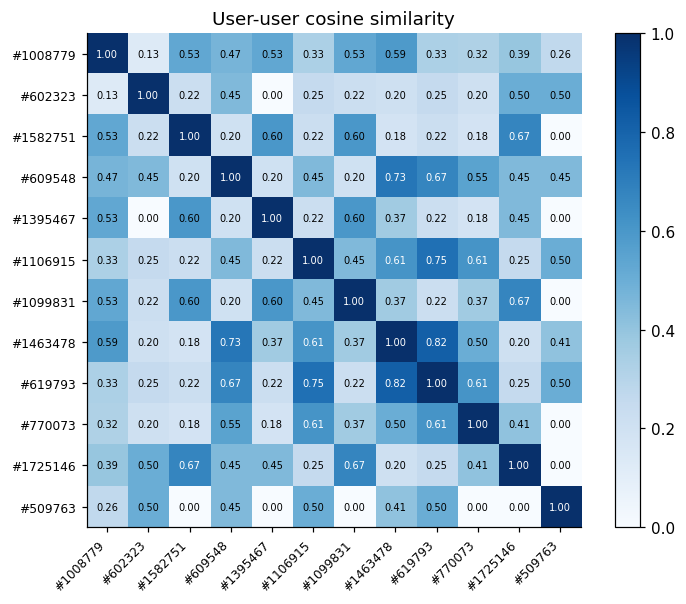

In [6]:
def ranked(scores, exclude_mask, tiebreak=None):
    # Indices of items sorted by score (desc), ties broken by `tiebreak` (desc).
    # Excluded or NaN items are dropped.
    tb = np.zeros(len(scores)) if tiebreak is None else tiebreak
    idx = [j for j in range(len(scores)) if not exclude_mask[j] and not np.isnan(scores[j])]
    return sorted(idx, key=lambda j: (-round(scores[j], 9), -tb[j]))

# Almost every enrollment is a completion (3), so many predictions tie at 3.00.
# Ties are broken by support: a course backed by more (and closer) neighbours ranks higher.
cf_rank = ranked(cf_pred, rated_mask[TARGET], tiebreak=cf_support)
print(f"User-based CF ranked recommendations for {users[TARGET]}:")
for r, j in enumerate(cf_rank, 1):
    who = [f"{users[v]}={int(R[v, j])}" for v in neighbors if R[v, j] > 0]
    print(f"  {r}. {items[j]:<30} predicted {cf_pred[j]:.2f}  support {cf_support[j]:.2f}"
          f"   (from {', '.join(who)})")
unscored = [short[j] for j in np.where(~rated_mask[TARGET] & np.isnan(cf_pred))[0]]
print(f"\nCannot be scored by CF (no neighbor took them): {unscored}")

# Neighbour similarity heatmap
fig, ax = plt.subplots(figsize=(7, 5.6))
im = ax.imshow(S, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_users), users, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_users), users, fontsize=8)
for i in range(n_users):
    for j in range(n_users):
        ax.text(j, i, f"{S[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if S[i, j] > 0.6 else "black")
ax.set_title("User-user cosine similarity"); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); save_fig(fig, "fig_user_similarity"); plt.show()

## 3. Content-based filtering

**Item features: the 14 real genre tags from IBM's `course_genre.csv`** (multi-hot). Each course carries 1–3 tags, for example *Spark Fundamentals I* = Database + DataAnalysis + BigData.

**User profile.** A weighted average of the feature vectors of the courses the learner took. The weights are **mean-centered values** ($r_{u,i}-\bar r_u$). Here that means completions pull the profile *toward* a course's tags and an audit pushes it *away*. Each course the learner hasn't taken is ranked by cosine similarity to the profile. When cosine similarities tie (often at 0), the more popular course on the platform ranks first.

In [7]:
feature_names = GENRES          # 14 binary genre tags from IBM's course_genre.csv
assert F.shape == (n_items, len(feature_names))

print("Genre tags of the 15 courses:")
for j in range(n_items):
    print(f"  {short[j]:<10} {[g for g, v in zip(GENRES, F[j]) if v]}")

def cbf_scores(R, F, u):
    # Profile = mean-centred-rating-weighted average of rated item features; score = cosine.
    rated = np.where(R[u] > 0)[0]
    weights = R[u, rated] - R[u, rated].mean()
    if np.allclose(weights, 0):          # all ratings equal -> fall back to plain average
        weights = np.ones_like(weights)
    profile = weights @ F[rated] / np.abs(weights).sum()
    scores = np.array([cosine_sim(profile, F[i]) for i in range(len(F))])
    return scores, profile

cbf_score, profile = cbf_scores(R, F, TARGET)
print(f"\n{users[TARGET]}'s content profile (genres with non-zero weight):")
for name, val in zip(feature_names, profile):
    if abs(val) > 1e-9:
        print(f"  {name:<16} {val:+.3f}  {'#' * int(abs(val) * 60)}")

cbf_rank = ranked(cbf_score, rated_mask[TARGET], tiebreak=pop)   # ties -> more popular first
print(f"\nContent-based ranked recommendations for {users[TARGET]}:")
for r, j in enumerate(cbf_rank, 1):
    print(f"  {r}. {items[j]:<30} cosine {cbf_score[j]:+.3f}")

Genre tags of the 15 courses:
  Python     ['Python', 'DataScience']
  IntroDS    ['DataScience']
  SQL        ['Database']
  DataAnlys  ['Python', 'DataAnalysis']
  DataViz    ['Python', 'DataAnalysis']
  Stats      ['DataAnalysis']
  ML-Py      ['Python', 'MachineLearning']
  DL-101     ['MachineLearning']
  DL-TF      ['MachineLearning']
  BigData    ['Database', 'BigData']
  Spark      ['Database', 'DataAnalysis', 'BigData']
  Cloud      ['CloudComputing']
  Docker     ['Containers']
  Chatbot    ['Chatbot']
  Blockchain ['BackendDev', 'Blockchain']

#1008779's content profile (genres with non-zero weight):
  Database         +0.083  ####
  Python           +0.250  ##############
  DataAnalysis     +0.250  ##############
  Containers       +0.083  ####
  DataScience      -0.417  #########################

Content-based ranked recommendations for #1008779:
  1. Spark Fundamentals I           cosine +0.344
  2. Machine Learning with Python   cosine +0.316
  3. Big Data 101           

## 4. Knowledge-based filtering (constraint-based)

The KBS does not use rating similarity. It combines two authored inputs:

1. **Knowledge base (authored for this notebook).** A level for each course (beginner, intermediate, advanced), taken from the title and IBM's published learning paths, and **prerequisite rules**. Examples: *Machine Learning with Python* requires *Python for Data Science* and *Data Analysis with Python*. *Spark Fundamentals I* requires *Big Data 101*. *Deep Learning with TensorFlow* requires *Deep Learning 101*. A prerequisite counts as met only if it was **completed (3)**. An audit (2) does not count, which puts IBM's two enrollment modes to direct use.
2. **Learning-goals form (hypothetical).** The dataset has no stated goals, so the target is given a plausible form for an analyst moving toward ML. **Goals:** MachineLearning and CloudComputing. **Target level:** intermediate. **Avoid:** Blockchain, which is off their career path.

**Hard constraints:** all prerequisites completed, and no avoided topic. Courses that pass are ranked by a **utility function**: 0.6 × goal-topic match + 0.2 × level fit + 0.2 × "next step" (the course builds on something the learner completed). If fewer than 5 courses pass, the system **relaxes constraints** (Felfernig & Burke, 2008). Relaxed courses carry a 0.25 penalty for each broken constraint and are ranked below every course that passed.

In [8]:
# ----- Knowledge base (authored for this notebook; not part of the IBM files) -----
# Level from the course title and IBM's published learning paths: 1 = beginner, 2 = intermediate, 3 = advanced
LEVEL = np.array([1, 1, 1, 2, 2, 1, 2, 1, 3, 1, 2, 1, 1, 1, 1], dtype=float)
PREREQS = {                                  # course -> courses that must be COMPLETED first
    "DA0101EN":   ["PY0101EN"],
    "DV0101EN":   ["PY0101EN"],
    "ML0101ENv3": ["PY0101EN", "DA0101EN"],
    "ML0120ENv2": ["PY0101EN", "ML0115EN"],
    "BD0211EN":   ["BD0101EN"],
}

# ----- The target's learning-goals form (hypothetical: the dataset has no stated goals) -----
requirements = {
    "goal_topics":  ["MachineLearning", "CloudComputing"],
    "target_level": 2,
    "avoid_topics": ["Blockchain"],
}
UTILITY_W = {"topic": 0.6, "level": 0.2, "next_step": 0.2}
RELAX_PENALTY = 0.25

def kbs_scores(R, u, req, exclude_mask, top_n=TOP_N):
    completed = R[u] == 3                                                  # an audit does NOT count
    goal_idx = [GENRES.index(t) for t in req["goal_topics"]]
    avoid_idx = [GENRES.index(t) for t in req["avoid_topics"]]
    topic = F[:, goal_idx].max(axis=1)                                     # 1 if any goal topic
    level = 1 - np.abs(LEVEL - req["target_level"]) / 2                   # 1 = exact level
    prereq_ok = np.array([all(completed[COURSES.index(p)] for p in PREREQS.get(c, []))
                          for c in COURSES])
    next_step = np.array([bool(PREREQS.get(c)) for c in COURSES]) & prereq_ok  # builds on a completion
    utility = (UTILITY_W["topic"] * topic + UTILITY_W["level"] * level
               + UTILITY_W["next_step"] * next_step)

    avoid_hit = F[:, avoid_idx].max(axis=1) > 0 if avoid_idx else np.zeros(len(F), bool)
    violations = (~prereq_ok).astype(int) + avoid_hit.astype(int)
    passes = (violations == 0) & ~exclude_mask
    scores = np.where(passes, utility, np.nan)

    relaxed = []
    if passes.sum() < top_n:                               # constraint relaxation
        cand = np.where(~passes & ~exclude_mask)[0]
        penalised = utility[cand] - RELAX_PENALTY * violations[cand]
        # place relaxed items strictly below all passing items
        floor = np.nanmin(scores) if passes.any() else 1.0
        order = cand[np.argsort(-penalised, kind="stable")][: top_n - passes.sum()]
        for rank, j in enumerate(order):
            scores[j] = min(penalised[cand == j][0], floor - 1e-3 * (rank + 1))
            relaxed.append(j)
    return scores, utility, violations, relaxed, prereq_ok, avoid_hit

kbs_score, kbs_utility, kbs_viol, kbs_relaxed, kbs_pre, kbs_avoid = kbs_scores(
    R, TARGET, requirements, rated_mask[TARGET])

print(f"Constraint check for {users[TARGET]}'s unrated courses:")
for j in np.where(~rated_mask[TARGET])[0]:
    why = []
    if not kbs_pre[j]:
        why.append("prerequisite not completed: " + ", ".join(
            short[COURSES.index(p)] for p in PREREQS[COURSES[j]] if R[TARGET, COURSES.index(p)] != 3))
    if kbs_avoid[j]:
        why.append("avoided topic")
    status = "PASS" if not why else "FAIL (" + "; ".join(why) + ")"
    print(f"  {items[j]:<30} level={LEVEL[j]:.0f}  utility={kbs_utility[j]:.2f}  {status}")

kbs_rank = ranked(kbs_score, rated_mask[TARGET], tiebreak=pop)
print(f"\nKnowledge-based ranked recommendations for {users[TARGET]}:")
for r, j in enumerate(kbs_rank, 1):
    note = "  (relaxed)" if j in kbs_relaxed else ""
    print(f"  {r}. {items[j]:<30} score {kbs_score[j]:.3f}{note}")

Constraint check for #1008779's unrated courses:
  Machine Learning with Python   level=2  utility=1.00  PASS
  Deep Learning 101              level=1  utility=0.70  PASS
  Deep Learning with TensorFlow  level=3  utility=0.70  FAIL (prerequisite not completed: DL-101)
  Big Data 101                   level=1  utility=0.10  PASS
  Spark Fundamentals I           level=2  utility=0.20  FAIL (prerequisite not completed: BigData)
  Introduction to Cloud          level=1  utility=0.70  PASS
  Build Your Own Chatbot         level=1  utility=0.10  PASS
  Blockchain Essentials          level=1  utility=0.10  FAIL (avoided topic)

Knowledge-based ranked recommendations for #1008779:
  1. Machine Learning with Python   score 1.000
  2. Deep Learning 101              score 0.700
  3. Introduction to Cloud          score 0.700
  4. Big Data 101                   score 0.100
  5. Build Your Own Chatbot         score 0.100


## 5. Hybrid: prerequisite gate, then adaptive weighted blend (CF + CBF + KBS)

- **Gate (cascade step).** Courses that break a KBS hard constraint (a missing prerequisite or an avoided topic) are removed first. The notebook also prints the blend *without* the gate, to show why the gate is needed.
- **Blend (weighted step).** Each component is mapped onto an absolute [0, 1] scale. **CF:** (predicted value − 1) / 2, so audit = 0.5 and completion = 1, then **multiplied by support**. Without that step, every course that any neighbor completed would score a perfect 1.0. **CBF:** cosine clipped to [0, 1]. **KBS:** the utility score.
- **Adaptive weights.** Confidence in CF is α = min(n_enrollments / 5, 1). Weights: **CF = 0.5α**, **CBF = 0.3**, **KBS = 0.2 + 0.5(1 − α)**. With a rich history CF leads. With a sparse history the stated goals in KBS take over.
- A missing CF prediction (no neighbor took the course) is *unknown*, not a "no", so for that course the other two weights are renormalized.

In [9]:
def normalise_components(cf, cf_support, cbf, kbs, candidates):
    # Put all three component scores on an absolute [0, 1] scale over candidate items.
    sel = lambda x: np.where(candidates, x, np.nan)
    return {
        # 1 = browse, 2 = audit, 3 = complete -> 0, 0.5, 1; then shrunk by neighbour support
        "CF":  sel((cf - 1) / 2 * cf_support),
        "CBF": sel(np.clip(cbf, 0, 1)),
        "KBS": sel(np.nan_to_num(kbs, nan=0.0)),   # failed constraints = 0
    }

def hybrid_scores(cf, cf_support, cbf, kbs, n_ratings, candidates, full_history=5):
    alpha = min(n_ratings / full_history, 1.0)
    w = {"CF": 0.5 * alpha, "CBF": 0.3, "KBS": 0.2 + 0.5 * (1 - alpha)}
    comps = normalise_components(cf, cf_support, cbf, kbs, candidates)
    scores = np.full(len(cf), np.nan)
    for j in np.where(candidates)[0]:
        num = sum(w[k] * comps[k][j] for k in comps if not np.isnan(comps[k][j]))
        den = sum(w[k] for k in comps if not np.isnan(comps[k][j]))
        scores[j] = num / den if den > 0 else np.nan
    return scores, w, comps

candidates = ~rated_mask[TARGET]
hyb_blend, hyb_w, comps = hybrid_scores(cf_pred, cf_support, cbf_score, kbs_score,
                                        rated_mask[TARGET].sum(), candidates)
gate = ~np.isnan(kbs_score)                  # passes every hard constraint (or admitted by relaxation)
hyb_score = np.where(gate, hyb_blend, np.nan)
print(f"Hybrid weights for {users[TARGET]}:", {k: round(float(v), 2) for k, v in hyb_w.items()})

print(f"\nWeighted blend WITHOUT the gate (for comparison):")
for r, j in enumerate(ranked(hyb_blend, rated_mask[TARGET], tiebreak=pop), 1):
    parts = "  ".join(f"{k}={comps[k][j]:.2f}" if not np.isnan(comps[k][j]) else f"{k}= -- "
                      for k in comps)
    flag = "" if gate[j] else "   <-- breaks a hard constraint"
    print(f"  {r}. {items[j]:<30} {hyb_blend[j]:.3f}   [{parts}]{flag}")

hyb_rank = ranked(hyb_score, rated_mask[TARGET], tiebreak=pop)
print(f"\nFinal hybrid (gate, then blend) for {users[TARGET]}:")
for r, j in enumerate(hyb_rank, 1):
    print(f"  {r}. {items[j]:<30} {hyb_score[j]:.3f}")

Hybrid weights for #1008779: {'CF': 0.5, 'CBF': 0.3, 'KBS': 0.2}

Weighted blend WITHOUT the gate (for comparison):
  1. Introduction to Cloud          0.461   [CF=0.64  CBF=0.00  KBS=0.70]
  2. Machine Learning with Python   0.455   [CF=0.32  CBF=0.32  KBS=1.00]
  3. Spark Fundamentals I           0.282   [CF=0.36  CBF=0.34  KBS=0.00]   <-- breaks a hard constraint
  4. Deep Learning 101              0.280   [CF= --   CBF=0.00  KBS=0.70]
  5. Big Data 101                   0.231   [CF=0.36  CBF=0.11  KBS=0.10]
  6. Build Your Own Chatbot         0.180   [CF=0.32  CBF=0.00  KBS=0.10]
  7. Blockchain Essentials          0.000   [CF= --   CBF=0.00  KBS=0.00]   <-- breaks a hard constraint
  8. Deep Learning with TensorFlow  0.000   [CF= --   CBF=0.00  KBS=0.00]   <-- breaks a hard constraint

Final hybrid (gate, then blend) for #1008779:
  1. Introduction to Cloud          0.461
  2. Machine Learning with Python   0.455
  3. Deep Learning 101              0.280
  4. Big Data 101         

## 6. Comparison: top-5 recommendations from each approach for the target learner

In [10]:
methods = {"User-based CF": cf_rank, "Content-based": cbf_rank,
           "Knowledge-based": kbs_rank, "Hybrid": hyb_rank}

# ----- Comparison table -----
print(f"Top-{TOP_N} recommendations for {users[TARGET]}\n")
raw = {"User-based CF": cf_pred, "Content-based": cbf_score, "Knowledge-based": kbs_score,
       "Hybrid": hyb_score}
header = f"{'Rank':<5}" + "".join(f"{m:<22}" for m in methods)
print(header); print("-" * len(header))
for r in range(TOP_N):
    row = f"{r+1:<5}"
    for m, rank in methods.items():
        if r < len(rank):
            j = rank[r]
            relaxed_mark = " *" if m == "Knowledge-based" and j in kbs_relaxed else ""
            cell = f"{short[j]} ({raw[m][j]:.2f}){relaxed_mark}"
        else:
            cell = "- (no score)"
        row += f"{cell:<22}"
    print(row)
print("\nScores: CF = predicted rating (2 = audit, 3 = complete); CBF = cosine; KBS = utility; "
      "Hybrid = 0-1.\n* = returned only after constraint relaxation")

# ----- Consensus: how many methods put each course in their top-5 -----
top_sets = {m: set(rank[:TOP_N]) for m, rank in methods.items()}
votes = {j: sum(j in s for s in top_sets.values()) for j in np.where(candidates)[0]}
print("\nCourses by number of methods that place them in the top-5:")
for j, v in sorted(votes.items(), key=lambda kv: -kv[1]):
    print(f"  {v}/4  {items[j]}")

Top-5 recommendations for #1008779

Rank User-based CF         Content-based         Knowledge-based       Hybrid                
---------------------------------------------------------------------------------------------
1    Cloud (3.00)          Spark (0.34)          ML-Py (1.00)          Cloud (0.46)          
2    BigData (3.00)        ML-Py (0.32)          DL-101 (0.70)         ML-Py (0.46)          
3    Spark (3.00)          BigData (0.11)        Cloud (0.70)          DL-101 (0.28)         
4    ML-Py (3.00)          Blockchain (0.00)     BigData (0.10)        BigData (0.23)        
5    Chatbot (3.00)        DL-101 (0.00)         Chatbot (0.10)        Chatbot (0.18)        

Scores: CF = predicted rating (2 = audit, 3 = complete); CBF = cosine; KBS = utility; Hybrid = 0-1.
* = returned only after constraint relaxation

Courses by number of methods that place them in the top-5:
  4/4  Machine Learning with Python
  4/4  Big Data 101
  3/4  Deep Learning 101
  3/4  Introductio

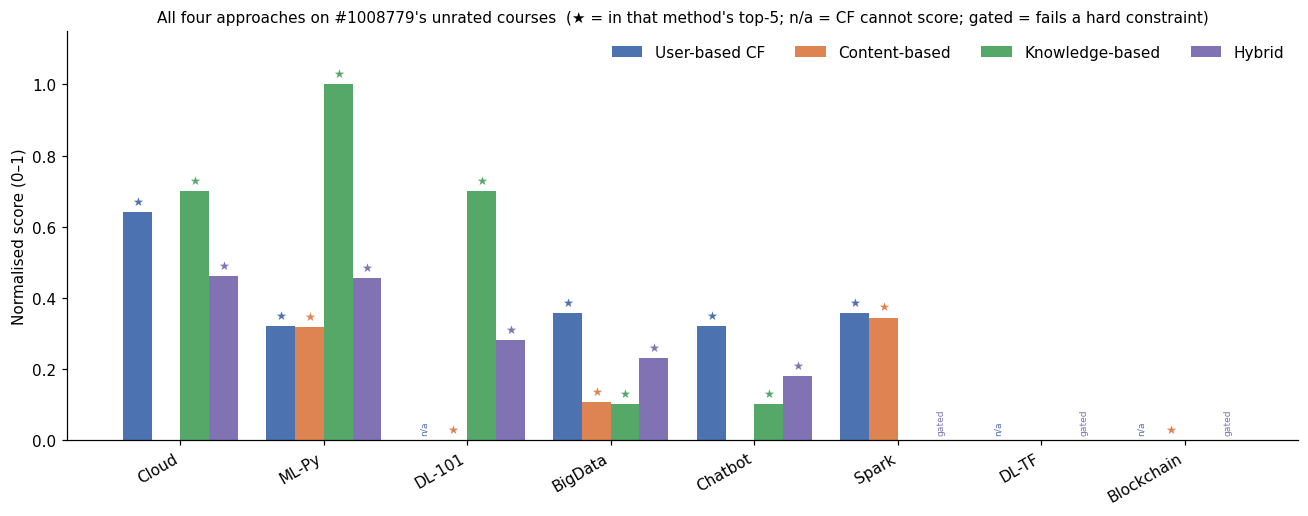

In [11]:
# ----- Grouped bar chart: normalised score of every candidate course under each method -----
cand_idx = np.where(candidates)[0]
norm_scores = {
    "User-based CF":   comps["CF"],
    "Content-based":   comps["CBF"],
    "Knowledge-based": comps["KBS"],
    "Hybrid":          hyb_score,
}
order = sorted(cand_idx, key=lambda j: (-np.nan_to_num(hyb_score[j], nan=-1), -hyb_blend[j]))  # by hybrid score
colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B3"]
x = np.arange(len(order)); width = 0.2

fig, ax = plt.subplots(figsize=(12, 4.8))
for k, (m, s) in enumerate(norm_scores.items()):
    vals = np.nan_to_num(s[order], nan=0.0)
    bars = ax.bar(x + (k - 1.5) * width, vals, width, label=m, color=colors[k])
    for b, j in zip(bars, order):                                  # mark top-5 membership
        if j in top_sets[m]:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, "★",
                    ha="center", fontsize=8, color=colors[k])
        if np.isnan(s[j]):
            ax.text(b.get_x() + b.get_width() / 2, 0.02, "gated" if m == "Hybrid" else "n/a", ha="center",
                    fontsize=6, rotation=90, color=colors[k])
ax.set_xticks(x, [short[j] for j in order], rotation=30, ha="right")
ax.set_ylabel("Normalised score (0–1)"); ax.set_ylim(0, 1.15)
ax.set_title(f"All four approaches on {users[TARGET]}'s unrated courses  (★ = in that method's top-5; "
             f"n/a = CF cannot score; gated = fails a hard constraint)", fontsize=10)
ax.legend(ncol=4, loc="upper right", frameon=False)
plt.tight_layout(); save_fig(fig, "fig_score_comparison"); plt.show()

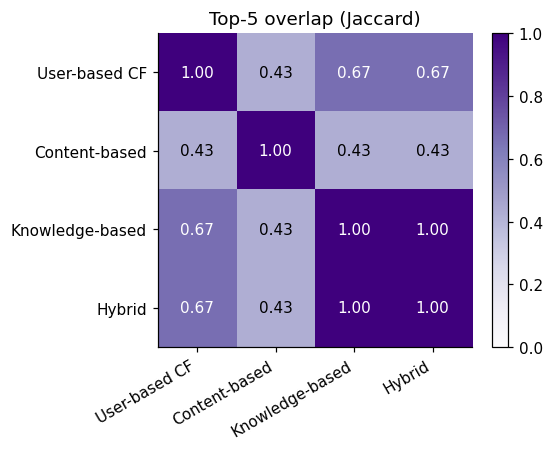

In [12]:
# ----- Pairwise top-5 overlap (Jaccard) between methods -----
names = list(methods)
J = np.array([[len(top_sets[a] & top_sets[b]) / len(top_sets[a] | top_sets[b]) for b in names] for a in names])

fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(J, cmap="Purples", vmin=0, vmax=1)
ax.set_xticks(range(4), names, rotation=30, ha="right"); ax.set_yticks(range(4), names)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{J[i, j]:.2f}", ha="center", va="center", color="white" if J[i, j] > 0.6 else "black")
ax.set_title("Top-5 overlap (Jaccard)"); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); save_fig(fig, "fig_top5_overlap"); plt.show()

### Commentary: where the approaches agree, where they differ, and what that shows

**Where they agree.** *Machine Learning with Python* and *Big Data 101* appear in all four top-5 lists. *Machine Learning with Python* is the strongest single recommendation: KBS utility 1.00 (it matches the ML goal, is intermediate level, and is the natural next step after the learner's completed Python and Data Analysis courses), CBF #2 (Python tag, and no Data Science tag), and a CF prediction of 3.00 from a neighbor who completed it. When behavioral, content and stated-goal signals point the same way, the recommendation is both accurate and easy to explain.

**What real implicit data does to CF.**
- **Saturation.** Every CF prediction is exactly **3.00**. With 95% of enrollments being completions, the weighted average can only say "a neighbor completed this", so the ranking comes entirely from the support tie-break. *Introduction to Cloud* ranks first only because two of the three neighbors took it.
- **Unstable neighborhoods.** Three learners tie for the 2nd and 3rd neighbor slots at 0.528, so which two are chosen depends on matrix order, not on the data. Cosine similarity on near-binary vectors produces many ties.
- **Sparsity.** CF cannot score *Deep Learning 101*, *Deep Learning with TensorFlow* or *Blockchain*, which is 3 of the 8 candidates, even in a matrix built from fairly active learners.

**Where CF and CBF differ (top-5 Jaccard = 0.43).** CBF ranks *Spark Fundamentals I* first (Database + DataAnalysis + BigData matches the profile), while CF has *Introduction to Cloud* first. CBF gives Cloud a cosine of 0: the learner has never taken a CloudComputing-tagged course, so content filtering cannot reach it. This is **over-specialization**, and CF provides the serendipity. The audited *Intro to Data Science* also gives the profile a strong negative Data Science weight (−0.42). An audit is a weak and ambiguous negative, since the learner may have already known the material. Finally, CBF's coarse tags score **5 of 8 candidates at exactly 0**, so its #4 and #5 (*Blockchain*, *Deep Learning 101*) are only popularity filler.

**Where KBS differs.** KBS is the only method that puts *Deep Learning 101* in its top-5 with real support. It is a stated goal with no trace in the learner's history, and no neighbor has taken it. KBS also **blocks** *Spark Fundamentals I*, because *Big Data 101* was never completed, and *Deep Learning with TensorFlow*, because *Deep Learning 101* is missing. History-based methods cannot see prerequisites at all: CF ranks Spark 3rd and CBF ranks it 1st.

**What the hybrid shows.** Without the gate, the weighted blend puts *Spark* **3rd**: CF and CBF outvote KBS's zero. That would recommend a course the learner isn't ready for. With the gate, the final list is *Cloud*, *ML with Python*, *Deep Learning 101*, *Big Data 101* and *Chatbot*. That is the same *set* as KBS (Jaccard = 1.0) in a different order: CF's peer evidence lifts Cloud above ML with Python. This is the architectural lesson from the real data. Prerequisites are hard constraints and belong in a **cascade (filter) step**. Goals and tastes are soft signals and belong in the **weighted blend**.

**Takeaway for the written analysis.** Each approach "sees" a different slice of the domain. CF sees peer behavior, but on real implicit data it saturates and becomes unstable. CBF sees item attributes but narrows toward what the learner already knows, and it is only as good as the tags. KBS sees intent and readiness but depends on authored rules and self-reported goals. The gated hybrid is the only list that is feasible, goal-aligned and supported by peers.

## 7. Cold-start check: a real learner with one enrollment

Learner #509763's only activity on the whole platform is *auditing* Introduction to Data Science. This learner is given a hypothetical goals form: DataAnalysis and Python topics, beginner level.

In [13]:
COLD = n_users - 1
cold_req = {"goal_topics": ["DataAnalysis", "Python"], "target_level": 1, "avoid_topics": []}
cold_cand = ~rated_mask[COLD]

cold_cf, cold_nb, cold_sims, cold_sup = user_cf_scores(R, COLD)
cold_cbf, _ = cbf_scores(R, F, COLD)
cold_kbs, _, _, cold_relaxed, *_ = kbs_scores(R, COLD, cold_req, rated_mask[COLD])
cold_blend, cold_w, _ = hybrid_scores(cold_cf, cold_sup, cold_cbf, cold_kbs, rated_mask[COLD].sum(), cold_cand)
cold_hyb = np.where(~np.isnan(cold_kbs), cold_blend, np.nan)     # same prerequisite gate

print(f"{users[COLD]}'s only enrollment:",
      {items[j]: int(R[COLD, j]) for j in np.where(rated_mask[COLD])[0]})
print(f"{users[COLD]}'s top-3 'neighbors':", [(users[v], round(float(cold_sims[v]), 3)) for v in cold_nb])
n_tied = int(np.isclose(cold_sims, cold_sims[cold_nb[-1]]).sum())
print(f"  ({n_tied} users tie at the 3rd-neighbor similarity {cold_sims[cold_nb[-1]]:.3f})")
print(f"Hybrid weights for {users[COLD]}:", {k: round(float(v), 2) for k, v in cold_w.items()}, "\n")
for m, (s, tb) in {"User-based CF": (cold_cf, cold_sup), "Content-based": (cold_cbf, pop),
                   "Knowledge-based": (cold_kbs, pop), "Hybrid": (cold_hyb, pop)}.items():
    top = ranked(s, rated_mask[COLD], tiebreak=tb)[:TOP_N]
    marks = [short[j] + ("*" if m == "Knowledge-based" and j in cold_relaxed else "") for j in top]
    print(f"{m:<16}: {marks}")
print("\n* = returned only after constraint relaxation")

#509763's only enrollment: {'Introduction to Data Science': 2}
#509763's top-3 'neighbors': [('#602323', 0.5), ('#1106915', 0.5), ('#619793', 0.5)]
  (3 users tie at the 3rd-neighbor similarity 0.500)
Hybrid weights for #509763: {'CF': 0.1, 'CBF': 0.3, 'KBS': 0.6} 

User-based CF   : ['Python', 'BigData', 'ML-Py', 'DL-101', 'DL-TF']
Content-based   : ['Python', 'BigData', 'DataAnlys', 'ML-Py', 'Spark']
Knowledge-based : ['Python', 'Stats', 'BigData', 'Blockchain', 'DL-101']
Hybrid          : ['Python', 'Stats', 'BigData', 'Blockchain', 'DL-101']

* = returned only after constraint relaxation


**Cold-start commentary.** All three of this learner's "neighbors" have a similarity of exactly 0.500, and each match rests on **one shared course**. CF therefore returns 3.00 for every course those neighbors completed, including *Deep Learning with TensorFlow*, an advanced course, for someone who has not finished a single course. That's a textbook CF cold-start failure: similarity built on one data point looks precise but is really noise.

CBF does little better. The profile is a single course's tags (Data Science), so only *Python for Data Science* has a non-zero cosine, and the other four slots are filled by popularity.

KBS handles the case well. *Python for Data Science* and *Statistics 101* match the goals and need no prerequisites. *Data Analysis* and *Data Visualization with Python* are **blocked**, because Python has not been completed yet. That is the correct advice: take Python first. The remaining KBS slots (*Big Data 101*, *Blockchain*, *Deep Learning 101*) have low utility (0.2), so a production system should show only the two goal-matching courses. With α = 0.2, the adaptive hybrid moves weight to KBS (CF 0.1 / CBF 0.3 / KBS 0.6), and the prerequisite gate removes CF's advanced suggestions. As the learner completes courses, α rises toward 1 and CF gradually takes over. That is the switching behavior the Selection and Justification section argues for.

## 8. Scale check: does CF improve with the full platform?

The 12-learner matrix is small by design. Here user-based CF is run for the same target over **all 33,901 learners and all 126 courses**, keeping only the 8 candidate courses from §2 so the results can be compared.

In [14]:
# ----- 8. Scale check: user-based CF over all 33,901 learners and all 126 courses -----
if ONLINE:
    t = uidx[TARGET_ID]
    norms = np.linalg.norm(R_full, axis=1)
    sims_full = (R_full @ R_full[t]) / (norms * norms[t])
    sims_full[t] = -np.inf
    order_full = np.argsort(-sims_full, kind="stable")
    cand_cols = [iidx[COURSES[j]] for j in np.where(candidates)[0]]

    print(f"{users[TARGET]} has {int((R_full[t] > 0).sum())} enrollments across the full catalog.")
    print(f"Best similarity in the full population: {sims_full[order_full[0]]:.3f}; "
          f"{int(np.isclose(sims_full, sims_full[order_full[2]]).sum())} learners tie at the "
          f"3rd-neighbor value {sims_full[order_full[2]]:.3f}\n")

    def cf_full(k):
        # Same prediction and support as user_cf_scores, but over the whole platform.
        nb = order_full[:k]
        out = {}
        for c in cand_cols:
            raters = nb[R_full[nb, c] > 0]
            if len(raters):
                w = sims_full[raters]
                out[c] = (float(w @ R_full[raters, c] / w.sum()), float(w.sum() / sims_full[nb].sum()))
        return out, nb

    for k in (3, 50):
        preds, nb = cf_full(k)
        top = sorted(preds, key=lambda c: (-round(preds[c][0], 9), -preds[c][1]))[:TOP_N]
        print(f"k = {k:>2}: CF scores {len(preds)}/{len(cand_cols)} candidates; top-{TOP_N}: "
              f"{[f'{short[COURSES.index(all_items[c])]} ({preds[c][0]:.2f}, sup {preds[c][1]:.2f})' for c in top]}")
        if k == 3:
            mine = set(np.where(R_full[t] > 0)[0])
            for v in nb:
                took = set(np.where(R_full[v] > 0)[0])
                print(f"        neighbor #{all_users[v]} sim {sims_full[v]:.3f}: {len(took)} courses, "
                      f"{len(took - mine)} that {users[TARGET]} has not taken")
    print(f"\nSubset CF top-{TOP_N} (Section 2): {[short[j] for j in cf_rank[:TOP_N]]}")
else:
    print("Offline: the full dataset was not downloaded, so the scale check is skipped.")

#1008779 has 12 enrollments across the full catalog.
Best similarity in the full population: 0.801; 5 learners tie at the 3rd-neighbor value 0.801

k =  3: CF scores 0/8 candidates; top-5: []
        neighbor #1405214 sim 0.801: 8 courses, 0 that #1008779 has not taken
        neighbor #1429598 sim 0.801: 8 courses, 0 that #1008779 has not taken
        neighbor #1622865 sim 0.801: 8 courses, 0 that #1008779 has not taken
k = 50: CF scores 6/8 candidates; top-5: ['Chatbot (3.00, sup 0.08)', 'DL-101 (3.00, sup 0.06)', 'Cloud (3.00, sup 0.02)', 'DL-TF (3.00, sup 0.02)', 'BigData (3.00, sup 0.02)']

Subset CF top-5 (Section 2): ['Cloud', 'BigData', 'Spark', 'ML-Py', 'Chatbot']


**Scale commentary.** More data does *not* fix the CF problems. It makes them clearer.
- **Five learners tie** for the best similarity (0.801), so the top-3 is arbitrary.
- Each top-3 neighbor has **8 courses, all of which the target has already taken**. Their histories are subsets of the target's. Cosine similarity rewards this kind of overlap, but a neighbor whose history is contained in yours has **nothing new to recommend**, so k = 3 CF scores **0 of 8** candidates.
- With k = 50, CF covers 6 of 8 candidates, but every prediction is still 3.00 and support is tiny (at most 0.08). The ranking is almost entirely noise.

For implicit completion data, a production system would need a similarity that ignores histories contained in the target's, a larger k with shrinkage, or item-based or matrix-factorization CF designed for implicit feedback (Hu et al., 2008). This supports making CF one weighted, support-shrunk component rather than the primary engine.

## References

Aggarwal, C. C. (2016). *Recommender systems: The textbook*. Springer. https://doi.org/10.1007/978-3-319-29659-3

Boccenti, M. (2023). *Recommender_system_project: Online courses recommender system with machine learning* [Computer software; copies of the IBM Machine Learning Capstone labs]. GitHub. https://github.com/mboccenti/Recommender_system_project

Burke, R. (2002). Hybrid recommender systems: Survey and experiments. *User Modeling and User-Adapted Interaction, 12*(4), 331–370. https://doi.org/10.1023/A:1021240730564

Felfernig, A., & Burke, R. (2008). Constraint-based recommender systems: Technologies and research issues. In *Proceedings of the 10th International Conference on Electronic Commerce* (Article 3). ACM. https://doi.org/10.1145/1409540.1409544

Hu, Y., Koren, Y., & Volinsky, C. (2008). Collaborative filtering for implicit feedback datasets. In *2008 Eighth IEEE International Conference on Data Mining* (pp. 263–272). IEEE. https://doi.org/10.1109/ICDM.2008.22

IBM Skills Network. (n.d.-a). *Course recommender system datasets* [Data set]. IBM ML321EN Machine Learning Capstone. Ratings: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv; course genres: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv

IBM Skills Network. (n.d.-b). *Machine learning capstone* [MOOC; instructors Y. Luo & A. Arutyunov]. Coursera. https://www.coursera.org/learn/machine-learning-capstone

Luo, Y. (2021). *Exploratory data analysis on online course enrollment data* [Jupyter notebook lab]. In *Machine learning capstone* (IBM ML321EN). IBM Skills Network. Public copy in Boccenti (2023).

Pazzani, M. J., & Billsus, D. (2007). Content-based recommendation systems. In P. Brusilovsky, A. Kobsa, & W. Nejdl (Eds.), *The adaptive web: Methods and strategies of web personalization* (pp. 325–341). Springer. https://doi.org/10.1007/978-3-540-72079-9_10

Resnick, P., Iacovou, N., Suchak, M., Bergstrom, P., & Riedl, J. (1994). GroupLens: An open architecture for collaborative filtering of netnews. In *Proceedings of the 1994 ACM Conference on Computer Supported Cooperative Work* (pp. 175–186). ACM. https://doi.org/10.1145/192844.192905